Accuracy: 0.6111950915881202
              precision    recall  f1-score   support

           0       0.76      0.51      0.61     13361
           1       0.51      0.76      0.61      9131

    accuracy                           0.61     22492
   macro avg       0.64      0.63      0.61     22492
weighted avg       0.66      0.61      0.61     22492

Saved tree image.


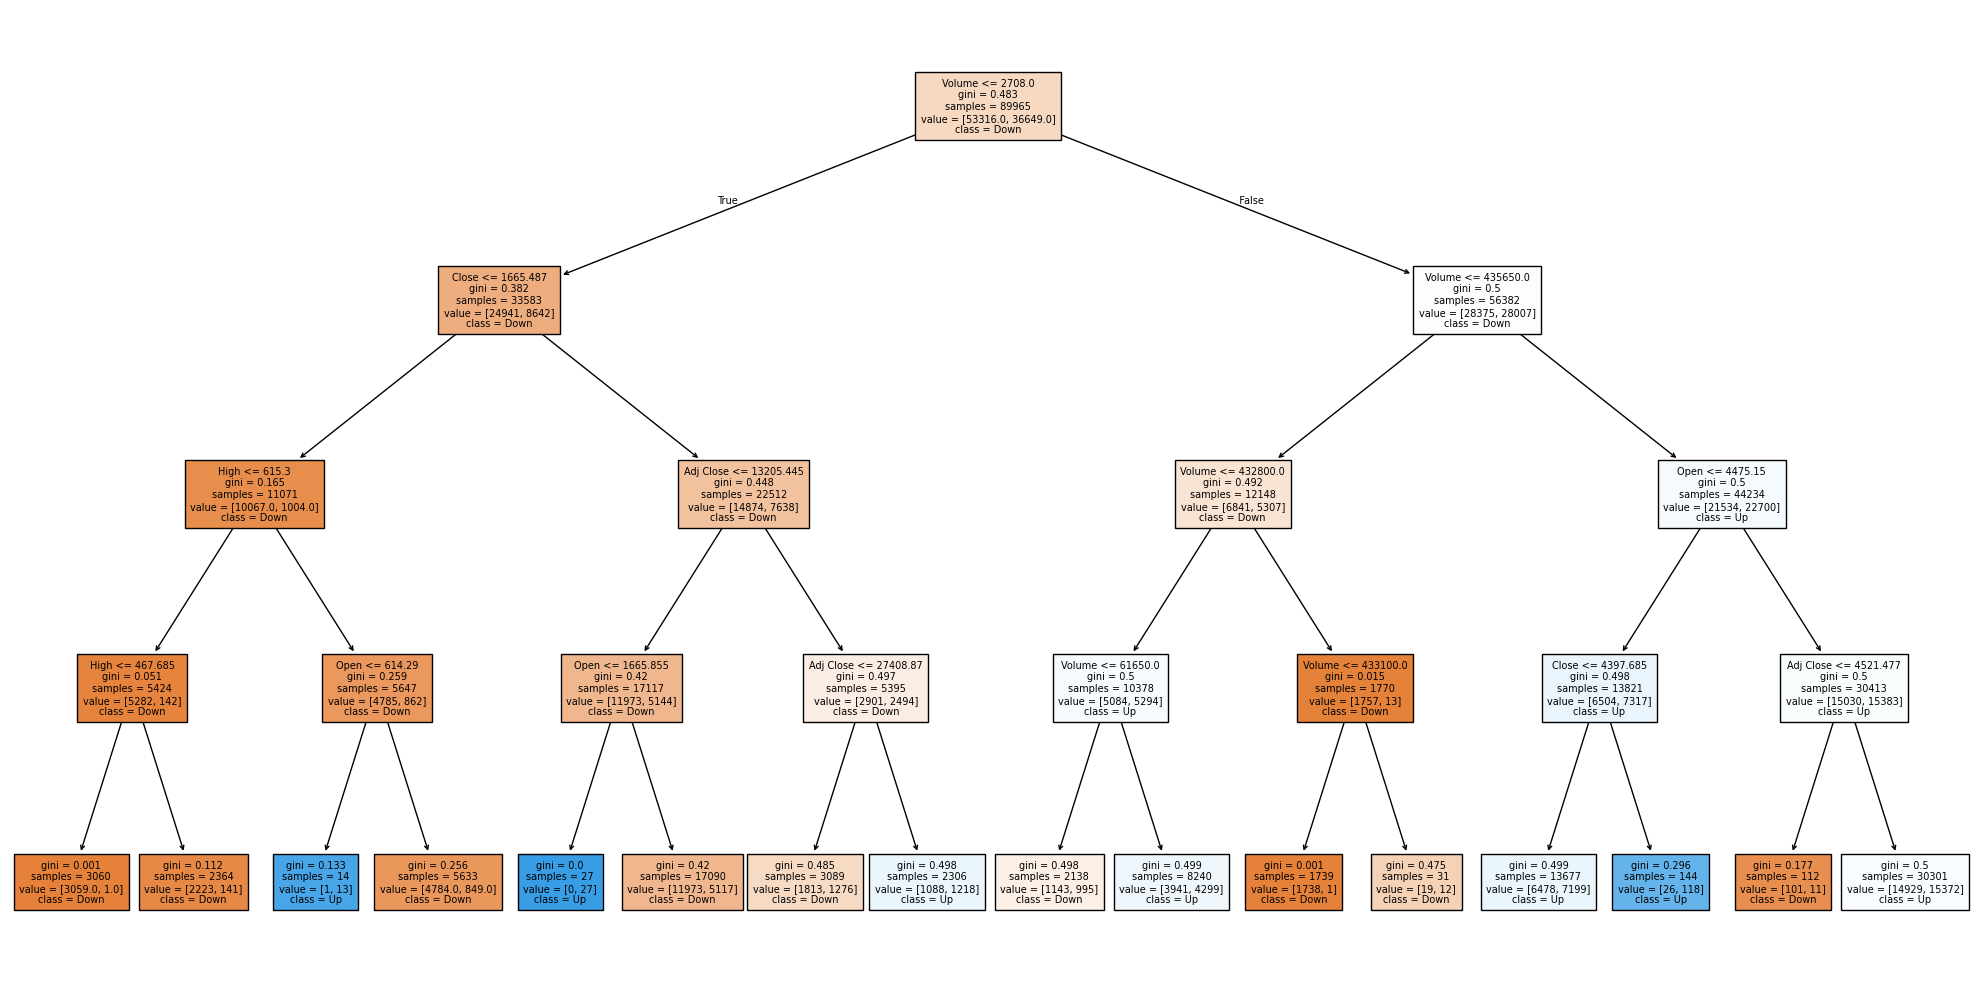

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv('indexData.csv')

# Drop irrelevant columns and create a target variable (e.g., predicting if Close > Open)
df = df.drop(columns=['Index', 'Date'])
df['Target'] = (df['Close'] > df['Open']).astype(int)

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Down', 'Up'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print("Saved tree image.")

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42

# ---------------------------------------------------------------------
# 1. Load the index dataset
# ---------------------------------------------------------------------
df = pd.read_csv("indexData.csv")

# Drop irrelevant columns and create a binary target (Close > Open)
df = df.drop(columns=['Index', 'Date'])
df['Target'] = (df['Close'] > df['Open']).astype(int)

# Handle missing values
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

TARGET = "Target"
DROP_COLS = ["Target"]
feature_names = [c for c in df.columns if c not in DROP_COLS]

X = df[feature_names].values
y = df[TARGET].values

# ---------------------------------------------------------------------
# 2. Train / test split
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# ---------------------------------------------------------------------
# 3. Train a Random Forest
# ---------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=20,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ---------------------------------------------------------------------
# 4. Evaluate
# ---------------------------------------------------------------------
y_pred = rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nOOB score: {rf.oob_score_:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------------------
# 5. Feature importances
# ---------------------------------------------------------------------
print("\nFeature importances:")
for name, importance in sorted(
    zip(feature_names, rf.feature_importances_), key=lambda x: -x[1]
):
    print(f" {name}: {importance:.4f}")


OOB score: 0.8931
Test accuracy: 0.9164

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     13361
           1       0.92      0.87      0.89      9131

    accuracy                           0.92     22492
   macro avg       0.92      0.91      0.91     22492
weighted avg       0.92      0.92      0.92     22492


Feature importances:
 Open: 0.2757
 Adj Close: 0.1856
 Close: 0.1836
 High: 0.1296
 Low: 0.1294
 Volume: 0.0961


/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
